In [138]:
import pandas as pd 





In [139]:
df = pd.read_csv('../artifact/04_06_2026_19_21_35/data_ingestion/feature_store/data.csv')

In [140]:
df['order_status'].value_counts(normalize=True)

order_status
delivered      0.978134
shipped        0.010608
canceled       0.004818
invoiced       0.003178
processing     0.003178
unavailable    0.000059
approved       0.000025
Name: proportion, dtype: float64

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118310 entries, 0 to 118309
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118310 non-null  object 
 1   customer_id                    118310 non-null  object 
 2   order_status                   118310 non-null  object 
 3   order_purchase_timestamp       118310 non-null  object 
 4   order_approved_at              118295 non-null  object 
 5   order_delivered_carrier_date   117056 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  118310 non-null  object 
 8   payment_sequential             118307 non-null  float64
 9   payment_type                   118307 non-null  object 
 10  payment_installments           118307 non-null  float64
 11  payment_value                  118307 non-null  float64
 12  review_id                     

In [142]:
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
payment_sequential               float64
payment_type                      object
payment_installments             float64
payment_value                    float64
review_id                         object
review_score                     float64
review_comment_title              object
review_comment_message            object
review_creation_date              object
review_answer_timestamp           object
order_item_id                      int64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
customer_unique_

In [143]:
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns


['payment_sequential',
 'payment_installments',
 'payment_value',
 'review_score',
 'order_item_id',
 'price',
 'freight_value',
 'customer_zip_code_prefix']

In [144]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
categorical_columns

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'payment_type',
 'review_id',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'customer_unique_id',
 'customer_city',
 'customer_state']

In [145]:

train_df = pd.read_csv('../artifact/04_06_2026_19_21_35/data_ingestion/ingested/train.csv')
test_df = pd.read_csv('../artifact/04_06_2026_19_21_35/data_ingestion/ingested/test.csv')

In [146]:
train_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state'],
      dtype='object')

In [147]:
test_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state'],
      dtype='object')

In [148]:
train_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.7,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
1,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,1.0,boleto,1.0,35.95,fc4af8aea8ec3f1a3cd181d3d0cadbd5,1.0,NaN,NaN,2017-02-03 00:00:00,2017-02-05 01:58:35,1,ac1789e492dcd698c5c10b97a671243a,63b9ae557efed31d1f7687917d248a8d,2017-01-27 18:29:09,19.9,16.05,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS
2,d22e9fa5731b9e30e8b27afcdc2f8563,756fb9391752dad934e0fe3733378e57,delivered,2018-08-04 23:25:30,2018-08-04 23:35:13,2018-08-06 15:03:00,2018-08-13 23:34:42,2018-09-13 00:00:00,1.0,debit_card,1.0,121.62,fcecdc18c0d4da82a2327b8b0d6e284a,4.0,NaN,NaN,2018-08-14 00:00:00,2018-08-15 09:20:30,1,f410090aec61f7c73748ca894286edcd,980640c45d7a4635885491d077167e4d,2018-08-07 23:35:13,99.0,22.62,394b2ce444baae9ae609f5d32000de0f,47850,luis eduardo magalhaes,BA
3,688052146432ef8253587b930b01a06d,81e08b08e5ed4472008030d70327c71f,delivered,2018-04-22 08:48:13,2018-04-24 18:25:22,2018-04-23 19:19:14,2018-04-24 19:31:58,2018-05-15 00:00:00,1.0,credit_card,3.0,346.09,c7862c2b2f4259f9b1173a9c14e737e5,4.0,Produto entregue em parte,Somente a Mala Pequena Bordo Avião 360º Viagem...,2018-04-25 00:00:00,2018-04-27 22:09:02,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-04-26 09:31:11,119.0,24.97,0e764fc1a13e47e900c3d59a989753e8,36045,juiz de fora,MG
4,688052146432ef8253587b930b01a06d,81e08b08e5ed4472008030d70327c71f,delivered,2018-04-22 08:48:13,2018-04-24 18:25:22,2018-04-23 19:19:14,2018-04-24 19:31:58,2018-05-15 00:00:00,1.0,credit_card,3.0,346.09,c7862c2b2f4259f9b1173a9c14e737e5,4.0,Produto entregue em parte,Somente a Mala Pequena Bordo Avião 360º Viagem...,2018-04-25 00:00:00,2018-04-27 22:09:02,2,db56f6d2b04c89eae4daba188842fd7b,2a84855fd20af891be03bc5924d2b453,2018-04-26 09:31:11,199.0,3.12,0e764fc1a13e47e900c3d59a989753e8,36045,juiz de fora,MG


In [149]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88798 entries, 0 to 88797
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       88798 non-null  object 
 1   customer_id                    88798 non-null  object 
 2   order_status                   88798 non-null  object 
 3   order_purchase_timestamp       88798 non-null  object 
 4   order_approved_at              88785 non-null  object 
 5   order_delivered_carrier_date   87848 non-null  object 
 6   order_delivered_customer_date  86841 non-null  object 
 7   order_estimated_delivery_date  88798 non-null  object 
 8   payment_sequential             88798 non-null  float64
 9   payment_type                   88798 non-null  object 
 10  payment_installments           88798 non-null  float64
 11  payment_value                  88798 non-null  float64
 12  review_id                      88060 non-null 

In [150]:
train_df = train_df[train_df['order_status']=='delivered']

In [151]:
train_df['order_purchase_timestamp'] = pd.to_datetime(train_df['order_purchase_timestamp']).dt.date    

In [152]:
train_df['order_purchase_timestamp']

0        2018-07-24
1        2017-01-23
2        2018-08-04
3        2018-04-22
4        2018-04-22
            ...    
88793    2017-11-05
88794    2017-10-04
88795    2017-10-04
88796    2017-10-04
88797    2017-10-04
Name: order_purchase_timestamp, Length: 86839, dtype: object

In [153]:
train_sales = train_df.groupby('customer_unique_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'sum'
}).rename(columns={
    'payment_value': 'total_sales',
    'payment_installments': 'total_installments'
})

In [154]:
df = df[df['order_status']=='delivered']

In [155]:
# order_purchase_tim# Filter lagate waqt aakhri mein .copy() zaroor lagayein
df = df[df['order_status'] == 'delivered'].copy()

# Index reset karna (Best practice)
df = df.reset_index(drop=True)

# Ab apna Date wala code chalaiye, koi warning nahi aayegi!
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp']).dt.date

In [156]:
maxdate = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [157]:
maxdate

datetime.date(2018, 8, 30)

In [158]:
recency_df = df.groupby('customer_unique_id').agg(
    Last_Purchase_Date = ('order_purchase_timestamp', 'max')
).reset_index()

recency_df['Recency'] = (maxdate - recency_df['Last_Purchase_Date'])


recency_df['Recency'] = pd.to_timedelta(recency_df['Recency']).dt.days
print(recency_df[['customer_unique_id', 'Recency']].head())

                 customer_unique_id  Recency
0  0000366f3b9a7992bf8c76cfdf3221e2      112
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115
2  0000f46a3911fa3c0805444483337064      538
3  0000f6ccb0745a6a4b88665a16c9f078      322
4  0004aac84e0df4da2b147fca70cf8255      289


In [159]:

reference_date = maxdate


rfm_train = train_df.groupby('customer_unique_id').agg(
    
    # [R] Recency: Aakhri baar shopping kab ki thi?
    Last_Purchase_Date = ('order_purchase_timestamp', 'max'),
    
    # [F] Frequency: Total kitne (unique) orders lagaye hain?
    Frequency = ('order_id', 'nunique'),
    
    # [M] Monetary: Total kitne paise (sales) dukan mein diye?
    Monetary = ('payment_value','mean'),
    
    total_installments= ('payment_installments','sum')
    
    
).reset_index()

rfm_train['Recency'] = (reference_date - rfm_train['Last_Purchase_Date'])
rfm_train['Recency'] = pd.to_timedelta(rfm_train['Recency']).dt.days


rfm_train = rfm_train.drop(columns=['Last_Purchase_Date'])

print(rfm_train.head())

                 customer_unique_id  Frequency  ...  total_installments  Recency
0  0000b849f77a49e4a4ce2b2a4ca5be3f          1  ...                 1.0      115
1  0000f6ccb0745a6a4b88665a16c9f078          1  ...                 4.0      322
2  0004aac84e0df4da2b147fca70cf8255          1  ...                 6.0      289
3  00050ab1314c0e55a6ca13cf7181fecf          1  ...                 1.0      132
4  00053a61a98854899e70ed204dd4bafe          1  ...                 6.0      183

[5 rows x 5 columns]


In [160]:
import numpy as np
rfm_train['Churn_Status'] = np.where(rfm_train['Recency'] > 349, 1, 0)

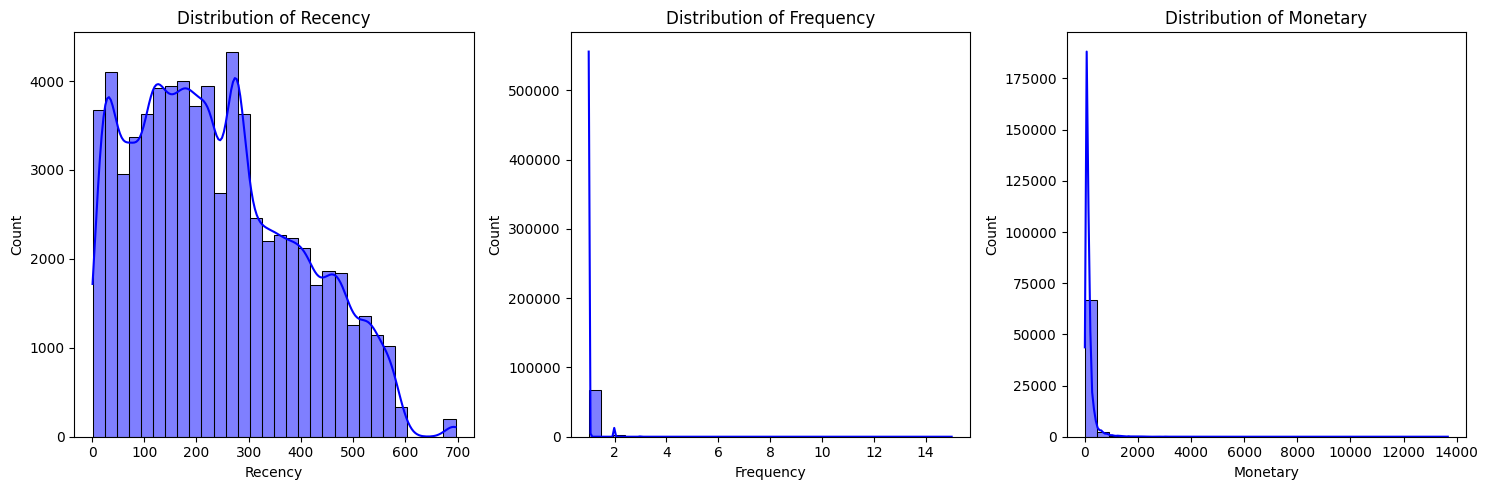

In [161]:


import seaborn as sns
import matplotlib.pyplot as plt


cols_to_plot = ['Recency', 'Frequency', 'Monetary']


plt.figure(figsize=(15, 5))

for i, col in enumerate(cols_to_plot):
    plt.subplot(1, 3, i+1)
    
  
    sns.histplot(rfm_train[col], kde=True, bins=30, color='blue')
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [162]:
rfm_train.describe()

,Frequency,Monetary,total_installments,Recency,Churn_Status
count,70003.000000,70003.000000,70003.000000,70003.000000,70003.000000
mean,1.033670,158.663372,3.667657,238.650301,0.246689
std,0.211645,222.103103,4.910614,152.592502,0.431087
min,1.000000,3.166667,0.000000,1.000000,0.000000
25%,1.000000,60.640000,1.000000,115.000000,0.000000
50%,1.000000,103.550000,2.000000,220.000000,0.000000
75%,1.000000,174.420000,4.000000,347.000000,0.000000
max,15.000000,13664.080000,240.000000,696.000000,1.000000


### 1. TARGET-BASED GROUPBY ANALYSIS

In [163]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')

print("--- Average RFM Values by Churn Status ---")
rfm_summary = rfm_train.groupby('Churn_Status')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
display(rfm_summary)

print("\n[ACTION STEP]:")
print("1. Compare the 'Recency' of Churn=1 vs Churn=0 to validate our threshold.")
print("2. Check if Active customers (0) naturally spend more (Monetary) than Churned ones (1).")

--- Average RFM Values by Churn Status ---


,Recency,Frequency,Monetary
Churn_Status,,,
0,168.32,1.04,158.87
1,453.43,1.03,158.04



[ACTION STEP]:
1. Compare the 'Recency' of Churn=1 vs Churn=0 to validate our threshold.
2. Check if Active customers (0) naturally spend more (Monetary) than Churned ones (1).


In [164]:
rfm_train.columns

Index(['customer_unique_id', 'Frequency', 'Monetary', 'total_installments',
       'Recency', 'Churn_Status'],
      dtype='object')

<Axes: xlabel='Churn_Status'>

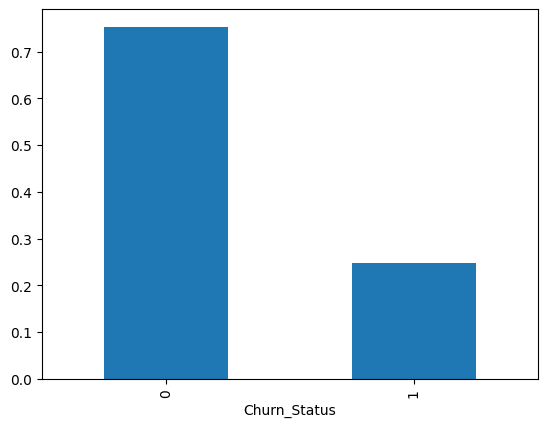

In [165]:
rfm_train['Churn_Status'].value_counts(normalize=True).plot(kind='bar')

In [166]:


def calculate_order_gaps(df):
    # 1. Date ko datetime mein badalna
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
    
    # 2. Customer ke level par min (pahla) aur max (aakhiri) order date nikalna
    # Saath mein 'count' bhi nikalenge taaki repeat customers pata chalein
    lifecycle_df = df.groupby('customer_unique_id')['order_purchase_timestamp'].agg(['min', 'max', 'count']).reset_index()
    
    # 3. First aur Last order ke beech ka difference (Days mein)
    lifecycle_df['tenure_days'] = (lifecycle_df['max'] - lifecycle_df['min']).dt.days
    
    # 4. Average Gap nikalna (Sirf Repeat Customers ke liye)
    # Agar 2 orders hain aur gap 60 din hai, toh avg wait 60 din hua.
    # Formula: Total Gap / (Total Orders - 1)
    repeat_customers = lifecycle_df[lifecycle_df['count'] > 1].copy()
    repeat_customers['avg_wait_between_orders'] = repeat_customers['tenure_days'] / (repeat_customers['count'] - 1)
    
    return repeat_customers




In [167]:
result_df = calculate_order_gaps(df)
avg_wait = result_df['avg_wait_between_orders'].mean()
print(f"Average wait time after first order: {avg_wait:.2f} days")

Average wait time after first order: 13.41 days


## remove customer whose frequency is one and recec below than 39 days

In [168]:
rfm_train = rfm_train[(rfm_train['Frequency'] == 1) & (rfm_train['Recency'] > 39)]

In [169]:
rfm_train = rfm_train.drop(columns=['customer_unique_id',])

In [170]:
from src.constants import REFRENCE_DATE
ref_date = pd.to_datetime(REFRENCE_DATE).date()

In [171]:
ref_date


datetime.date(2018, 8, 30)

In [172]:
from src.logger import logging
from src.exception import MyException
from src.constants import SCHEMA_FILE_PATH, TARGET_COLUMN, REFRENCE_DATE, THRESHOLD_DAY
from src.utils.main_utils import read_yaml_file, save_object, save_numpy_array_data
import numpy as np
import sys
import os 

In [173]:
schema_config = read_yaml_file(file_path="../config/schema.yaml")

In [174]:
def data_cleaning(dataframe: pd.DataFrame) -> pd.DataFrame:
        """ 
        Method Name :   data_cleaning
        Description :   This method cleans the raw data by removing duplicates 
                        and filtering out incomplete/canceled orders.
        
        Output      :   DataFrame
        On Failure  :   Write an exception log and then raise an exception
        """
        try:
            logging.info('Data cleaning started')
            
            #  Remove duplicate rows
            logging.info('Removing duplicate rows')
            initial_rows = dataframe.shape[0]
            dataframe = dataframe.drop_duplicates()
            final_rows = dataframe.shape[0]
            logging.info(f"Removed {initial_rows - final_rows} duplicate rows.")
            
            # Filter successful orders
            logging.info("Filtering for 'delivered' orders only")
            dataframe = dataframe[dataframe['order_status'] == 'delivered']

            # fix date columns types
            date_columns = [
                            'order_purchase_timestamp',  
                            'order_delivered_customer_date',
                            'order_estimated_delivery_date'
                            ]

            dataframe[date_columns] = dataframe[date_columns].apply(pd.to_datetime , errors='coerce')
            dataframe[date_columns] = dataframe[date_columns].apply(lambda x: x.dt.date)
            
            # drop unnecessary columns
            logging.info(f"Drop unnecssary columns: {schema_config['drop_columns']}")
            dataframe.drop(columns= schema_config['drop_columns'],inplace=True)
            logging.info(f"Data cleaning completed. Final shape: {dataframe.shape}")

            return dataframe

        except Exception as e:
            raise MyException(e, sys) #type: ignore

In [175]:
train_cleaned = data_cleaning(dataframe= train_df)

[2026-04-06 20:20:49,242] root - INFO - Data cleaning started
[2026-04-06 20:20:49,242] root - INFO - Removing duplicate rows
[2026-04-06 20:20:49,682] root - INFO - Removed 0 duplicate rows.
[2026-04-06 20:20:49,682] root - INFO - Filtering for 'delivered' orders only
[2026-04-06 20:20:49,919] root - INFO - Drop unnecssary columns: ['customer_id', 'review_id', 'product_id', 'seller_id', 'order_item_id', 'review_comment_title', 'review_comment_message', 'order_approved_at', 'order_delivered_carrier_date', 'review_creation_date', 'review_answer_timestamp', 'shipping_limit_date', 'order_status', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_sequential', 'payment_type']
[2026-04-06 20:20:49,943] root - INFO - Data cleaning completed. Final shape: (86839, 10)


In [176]:
train_cleaned.head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,payment_installments,payment_value,review_score,price,freight_value,customer_unique_id
0,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24,2018-08-07,2018-08-13,1.0,141.46,4.0,118.7,22.76,af07308b275d755c9edb36a90c618231
1,76c6e866289321a7c93b82b54852dc33,2017-01-23,2017-02-02,2017-03-06,1.0,35.95,1.0,19.9,16.05,39382392765b6dc74812866ee5ee92a7
2,d22e9fa5731b9e30e8b27afcdc2f8563,2018-08-04,2018-08-13,2018-09-13,1.0,121.62,4.0,99.0,22.62,394b2ce444baae9ae609f5d32000de0f
3,688052146432ef8253587b930b01a06d,2018-04-22,2018-04-24,2018-05-15,3.0,346.09,4.0,119.0,24.97,0e764fc1a13e47e900c3d59a989753e8
4,688052146432ef8253587b930b01a06d,2018-04-22,2018-04-24,2018-05-15,3.0,346.09,4.0,199.0,3.12,0e764fc1a13e47e900c3d59a989753e8


In [177]:
def perform_feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
        """ 
        Method Name :   perform_feature_engineering
        Description :   This method applies feature engineering to the raw dataframe, 
                        calculates RFM (Recency, Frequency, Monetary) features, 
                        creates the 'Is_Churn' target variable, and drops unnecessary columns.
        
        Output      :   DataFrame
        On Failure  :   Write an exception log and then raise an exception
        """
        logging.info("Start feature engineering")
        try:
            date_columns = [
                            'order_purchase_timestamp',  
                            'order_delivered_customer_date',
                            'order_estimated_delivery_date'
                            ]

            df[date_columns] = df[date_columns].apply(pd.to_datetime , errors='coerce')
            df['delivery_delay'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
            df[date_columns] = df[date_columns].apply(lambda x: x.dt.date)
            
            logging.info("Making feature for model")
            ref_date = pd.to_datetime(REFRENCE_DATE).date()
            df = df.groupby('customer_unique_id').agg(
                Recency=('order_purchase_timestamp', lambda x: (ref_date - x.max()).days),
                Frequency=('order_id', 'nunique'),
                Monetary=('payment_value', 'sum'),
                Average_review_score = ('review_score', 'mean'),
                total_installments= ('payment_installments','sum'),
                Total_Price=('price', 'sum'),
                Total_Freight=('freight_value', 'sum'),
                Avg_delivery_delay = ('delivery_delay', 'mean')
            ).reset_index()
            
            # fright_ratio
            df['Freight_ratio'] = df['Total_Freight'] / df['Total_Price']
            
            df['Freight_ratio'] = df['Freight_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)
            df['Avg_delivery_delay'] = df['Avg_delivery_delay'].fillna(0)

            
           
            # making target (label)
            logging.info("Creating Target Variable: Is_Churn")
            df['Is_churn'] = (df['Recency'] > THRESHOLD_DAY).astype(int)

            # Drop columns
            logging.info(f"Dropping: {schema_config['transfromed_drop_columns']}")
            df.drop(columns=schema_config["transfromed_drop_columns"],inplace=True)

            logging.info('Feature engineering complete')
            return df
        
        except Exception as e:
             raise MyException(e,sys) # type: ignore

In [178]:
train_cleaned2 = perform_feature_engineering(df= train_df)

[2026-04-06 20:20:50,040] root - INFO - Start feature engineering
[2026-04-06 20:20:50,198] root - INFO - Making feature for model
[2026-04-06 20:20:54,630] root - INFO - Creating Target Variable: Is_Churn
[2026-04-06 20:20:54,646] root - INFO - Dropping: ['Recency', 'Total_Price', 'Total_Freight', 'customer_unique_id']
[2026-04-06 20:20:54,651] root - INFO - Feature engineering complete


In [179]:
train_cleaned2.head()

,Frequency,Monetary,Average_review_score,total_installments,Avg_delivery_delay,Freight_ratio,Is_churn
0,1,27.19,4.0,1.0,-5.0,0.438624,0
1,1,43.62,4.0,4.0,-12.0,0.678338,0
2,1,196.89,5.0,6.0,-8.0,0.093833,0
3,1,35.38,4.0,1.0,-12.0,0.264023,0
4,1,838.36,1.0,6.0,-10.0,0.097330,0


In [180]:
import sys
from typing import Tuple

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
# from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from src.exception import MyException
from src.logger import logging
from src.utils.main_utils import load_numpy_array_data, load_object, save_object,read_yaml_file
# from src.entity.config_entity import ModelTrainerConfig
# from src.entity.artifact_entity import DataTransformationArtifact, ModelTrainerArtifact, ClassificationMetricArtifact
# from src.entity.estimator import MyModel
# artifact\04_05_2026_23_08_38\data_transformation\transformed\test.npy

In [188]:
train_arr = load_numpy_array_data(file_path='../artifact/04_06_2026_19_21_35/data_transformation/transformed/train.npy')
test_arr = load_numpy_array_data(file_path='../artifact/04_06_2026_19_21_35/data_transformation/transformed/test.npy')


In [189]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'], # Alag-alag regularization
    'solver': ['saga'],                    # 'saga' ek aisa solver hai jo L1, L2 aur ElasticNet sab handle kar leta hai
    'class_weight': [None, 'balanced'],     # Churn imbalance handle karne ke liye
    'l1_ratio': [0.5],                      # Ye sirf tab kaam aayega jab penalty='elasticnet' ho
    'max_iter': [1000, 2000]                # convergence ke liye safety
}

In [190]:
X_train, y_train = train_arr[:, :-1], train_arr[:, -1]
X_test, y_test = test_arr[:, :-1], test_arr[:, -1]

In [191]:
lr_model = LogisticRegression()

In [192]:
grid_search = GridSearchCV(
                estimator=lr_model,
                param_grid=param_grid,
                cv=5,            # 5-Fold Cross Validation
                n_jobs=-1,       # CPU ke saare cores use karega speed ke liye
                verbose=2,       # Terminal me progress dikhayega
                scoring='precision'     # Churn ke liye F1-score sabse best hai
            )

In [193]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


KeyboardInterrupt: 

In [ ]:
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
f1

0.0030874785591766723

In [ ]:
recall

0.0015477214101461737

In [ ]:
precision

0.6

In [ ]:
accuracy

0.7511453650181974

In [ ]:
l2 = LogisticRegression(class_weight='balanced')

In [ ]:
model = l2.fit(X_train,y_train)

In [ ]:
predict = model.predict(X_test)

In [ ]:
f1_score(y_test, predict)

0.3939199064600994

In [ ]:
best_params

{'C': 100,
 'class_weight': 'balanced',
 'l1_ratio': 0.5,
 'max_iter': 2000,
 'penalty': 'l1',
 'solver': 'saga'}

In [ ]:
print(f"f1 score {f1}")
print(f"Accuracy score: {accuracy}")
print(f"Recall score: {recall}")
print(f"precision score: {precision}")

f1 score 0.3982235381199112
Accuracy score: 0.5474630700064226
Recall score: 0.6013757523645744
precision score: 0.2976676881171263


In [ ]:
model_config = read_yaml_file('../config/model.yaml')


In [ ]:
model_config

{'models': {'LogisticRegression': {'class_name': 'LogisticRegression',
   'module': 'sklearn.linear_model',
   'best_params': {'C': '100,',
    'class_weight': 'balanced',
    'l1_ratio': 0.5,
    'max_iter': 2000,
    'penalty': 'l1',
    'solver': 'saga'}},
  'RandomForestClassifier': {'class_name': 'RandomForestClassifier',
   'module': 'sklearn.ensemble',
   'best_params': {'n_estimators': 200,
    'max_depth': 10,
    'min_samples_split': 5,
    'class_weight': 'balanced'}}}}

In [ ]:
model_config['models']['LogisticRegression']['best_params']

{'C': '100,',
 'class_weight': 'balanced',
 'l1_ratio': 0.5,
 'max_iter': 2000,
 'penalty': 'l1',
 'solver': 'saga'}

In [ ]:
for model_name, model_info in model_config['models'].items():
                logging.info(f"Dynamically initializing {model_name}...")
                
                
                module_name = model_info['module']
                class_name = model_info['class_name']
                best_params = model_info.get('best_params', {})

[2026-04-06 11:26:06,445] root - INFO - Dynamically initializing LogisticRegression...
[2026-04-06 11:26:06,450] root - INFO - Dynamically initializing RandomForestClassifier...


In [ ]:
print(module_name)
print(model_name)
print(class_name)

sklearn.ensemble
RandomForestClassifier
RandomForestClassifier


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

In [ ]:
param_grid2 = {
    "criterion": ["gini", "entropy"], 
    "max_depth": [None, 10, 20, 30, 40, 50], 
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", None] 
}

In [ ]:
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid2,
    cv=5,                 # 3-fold cross-validation (Taaki zyada time na lage)
    scoring="f1",         # Kyunki hume Churn ke liye F1/Recall chahiye
    n_jobs=-1,            # Laptop ke saare CPU cores use karne ke liye
    verbose=2
)

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [ ]:
dt_best_model = grid_search.best_estimator_
dt_best_params = grid_search.best_params_

In [ ]:
y_pred = dt_best_model.predict(X_test)


In [ ]:
y_pred = dt_best_model.predict(X_test)

f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"f1 score {f1}")
print(f"Accuracy score: {accuracy}")
print(f"Recall score: {recall}")
print(f"precision score: {precision}")

In [ ]:
print(f"f1 score {f1}")
print(f"Accuracy score: {accuracy}")
print(f"Recall score: {recall}")
print(f"precision score: {precision}")

f1 score 0.38738379814077023
Accuracy score: 0.6049668165275102
Recall score: 0.5016337059329321
precision score: 0.3155219037317469


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Engine (Random Forest)
rf_model = RandomForestClassifier(random_state=42)

# Hyperparameter Grid (Jungle ka map)
param_grid_rf = {
    "n_estimators": [50, 100, 200, 300],      #
    "criterion": ["gini", "entropy"],        
    "max_depth": [10, 20, 30, 40, None],      
    "min_samples_split": [2, 5, 10],          
    "min_samples_leaf": [1, 2, 4],           
    "max_features": ["sqrt", "log2", None]    
}

# Randomized Search Setup (Fast & Smart)
rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid_rf,
    n_iter=15,            # Sirf 15 best combinations try karega (Time bachega!)
    cv=3,                 # 3-fold cross validation
    scoring="f1",         # Apna main metric (Kyunki hume churn pakadna hai)
    n_jobs=-1,            # Laptop ke saare CPU cores use karne ke liye
    verbose=2,            # Screen par progress dikhata rahega
    random_state=42
)

# Training chalu karein
print("Random Forest Training Started...")
rf_search.fit(X_train, y_train)
print(f"🏆 Best Parameters: {rf_search.best_params_}")
print(f"⭐ Best F1-Score: {rf_search.best_score_}")


Random Forest Training Started...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
🏆 Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40, 'criterion': 'gini'}
⭐ Best F1-Score: 0.89663580502329


In [196]:
best_rf_model = rf_search.best_estimator_

In [197]:
best_rf_model

,n_estimators,100
,criterion,'gini'
,max_depth,40
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [200]:
y_pred = best_rf_model.predict(X_test)

f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"f1 score {f1}")
print(f"Accuracy score: {accuracy}")
print(f"Recall score: {recall}")
print(f"precision score: {precision}")

f1 score 0.4131281780360563
Accuracy score: 0.61948190965532
Recall score: 0.5379191745485813
precision score: 0.3353344768439108
